# Used Car Price Prediction

### Importing libraries

In [164]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

### Reading Data

In [165]:
df=pd.read_csv(f'cardekho_dataset.csv',index_col=[0])

In [166]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Handling Missing values

In [167]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

No null values are present.

### Data Cleaning

In [168]:
df.shape

(15411, 13)

In [169]:
df.drop(['car_name'],axis=1,inplace=True)

In [170]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Exploratory Data Analysis

In [171]:
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
print(f'Numerical Features: {numerical_features} , Total: {len(numerical_features)}')

categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print(f'Categorical Features: {categorical_features} , Total: {len(categorical_features)}')

discrete_features=[feature for feature in numerical_features if len(df[feature].unique()) <=15]
print(f'Discrete Features: {discrete_features} , Total: {len(discrete_features)}')

continuous_features=[feature for feature in numerical_features if feature not in discrete_features]
print(f'Continuous Features: {continuous_features} , Total: {len(continuous_features)}')


Numerical Features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price'] , Total: 7
Categorical Features: ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'] , Total: 5
Discrete Features: ['seats'] , Total: 1
Continuous Features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price'] , Total: 6


In [172]:
for feature in categorical_features:
    print(f'{feature.capitalize()}:')
    print(df[feature].unique())
    print(f'Total: {len(df[feature].unique())}')
    print(f'\n{"-"*50}\n')
    print()

Brand:
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']
Total: 32

--------------------------------------------------


Model:
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' 'Z4' '6' 'XF' 'X5' 'Hector' 'Civic' 'D-Max'
 'Cayenne' 'X1' 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300' 'Dzire VXI'
 'S90' 'WR-V' 'XL6' 'Triber' 'ES' 'Wrangler' 'Camr

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15411 entries, 0 to 19543
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15411 non-null  object 
 1   model              15411 non-null  object 
 2   vehicle_age        15411 non-null  int64  
 3   km_driven          15411 non-null  int64  
 4   seller_type        15411 non-null  object 
 5   fuel_type          15411 non-null  object 
 6   transmission_type  15411 non-null  object 
 7   mileage            15411 non-null  float64
 8   engine             15411 non-null  int64  
 9   max_power          15411 non-null  float64
 10  seats              15411 non-null  int64  
 11  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 1.5+ MB


In [174]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [175]:
categorical_features

['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [176]:
for feature in categorical_features:
    print(f'{feature.capitalize()}:')
    print(df[feature].value_counts(normalize=True)*100)
    print(f'\n{"-"*50}\n')

Brand:
Maruti           32.392447
Hyundai          19.349815
Honda             9.635974
Mahindra          6.560249
Toyota            5.145675
Ford              5.126209
Volkswagen        4.023100
Renault           3.478035
BMW               2.848615
Tata              2.790215
Mercedes-Benz     2.186750
Skoda             2.167283
Audi              1.245863
Datsun            1.103108
Jaguar            0.382843
Land Rover        0.330932
Jeep              0.266044
Kia               0.207644
Porsche           0.136266
Volvo             0.129777
MG                0.123289
Mini              0.110311
Nissan            0.071378
Lexus             0.064889
Isuzu             0.051911
Bentley           0.019467
Maserati          0.012978
ISUZU             0.012978
Ferrari           0.006489
Mercedes-AMG      0.006489
Rolls-Royce       0.006489
Force             0.006489
Name: brand, dtype: float64

--------------------------------------------------

Model:
i20            5.878918
Swift Dzire    5.

In [177]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Univariate Analysis

#### Numerical Features

In [178]:
numerical_features

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

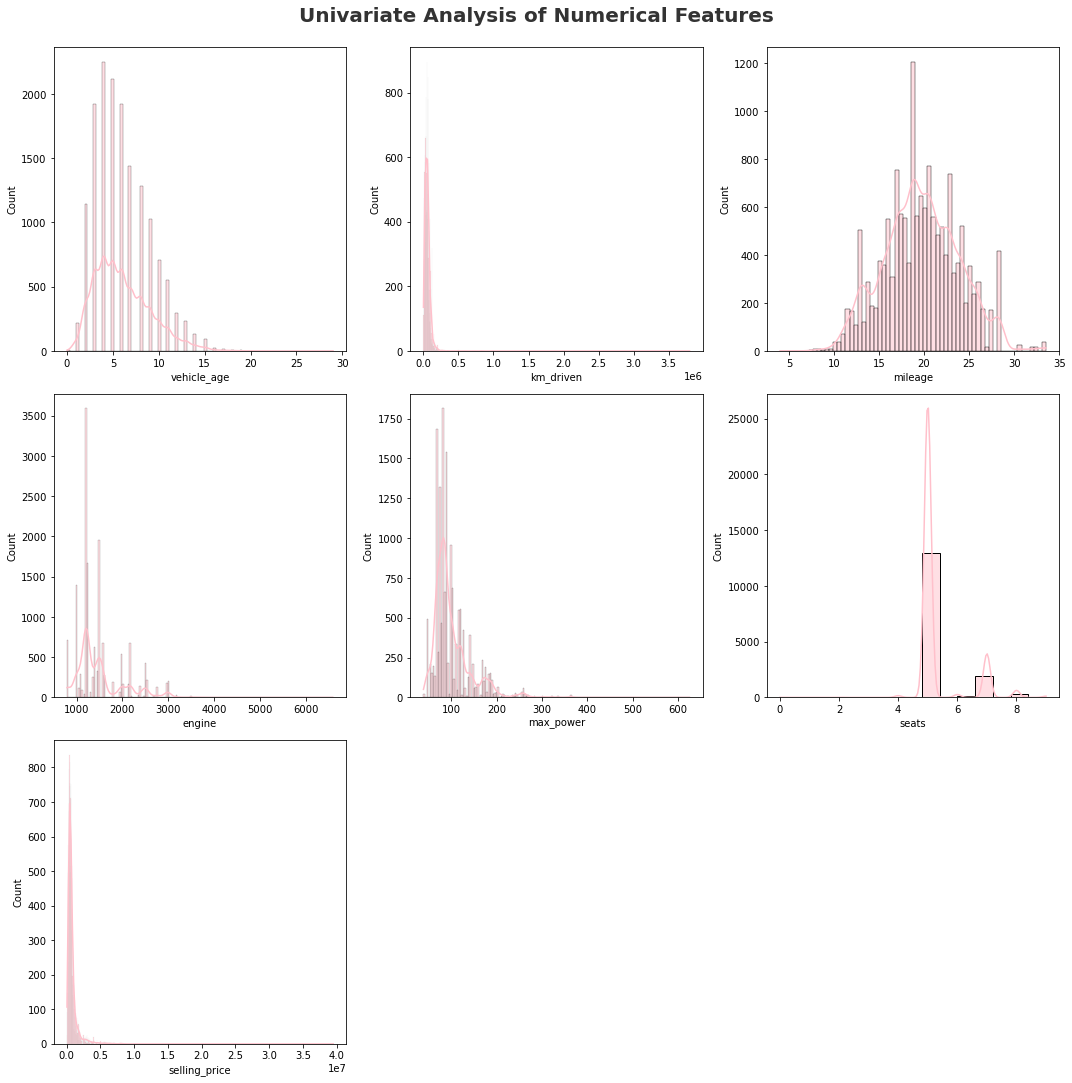

In [179]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1.0)

for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.histplot(x=df[numerical_features[i]],color='pink',kde=True)
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

In [ ]:
plt.figure(figsize=(15,15))
plt.suptitle('Box Plot of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1.0)

for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[numerical_features[i]])
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

#### Categorical Features

In [ ]:
categorical_features

In [ ]:
plt.figure(figsize=(20,15))
plt.suptitle('Univariate Analysis of Categorical Features',fontsize=20,fontweight='bold',y=1.0)

categorical_features1=['brand', 'seller_type', 'fuel_type', 'transmission_type']

for i in range(len(categorical_features1)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[categorical_features1[i]])
    plt.xticks(rotation=45)
    plt.xlabel(categorical_features1[i])
    plt.tight_layout()

### Bivariate Analaysis

In [ ]:
continuous_features

In [ ]:
plt.figure(figsize=(20,15))
plt.suptitle('Bivariate Analysis of Continuous features',fontsize=20,fontweight='bold',y=1.0)

for i in range(len(continuous_features)):
    plt.subplot(4,2,i+1)
    sns.scatterplot(y=continuous_features[i],x='selling_price',data=df)
    plt.xlim(0,25000000)
    plt.tight_layout()

### Multivariate Analysis

#### Numerical Features

In [ ]:
sns.heatmap(df[numerical_features].corr(),linecolor='white',linewidths=2,annot=True);

#### Categorical Features

In [ ]:

from scipy.stats import chi2_contingency


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))

    rcorr = r - ((r-1)**2)/(n-1)

    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

corr_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(categorical_features1))),
    index=categorical_features1,
    columns=categorical_features1
)

for col1 in categorical_features1:
    for col2 in categorical_features1:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Categorical Correlation Matrix (Cramer's V)")
plt.show()

In [ ]:
pd.crosstab(
    [df['brand'], df['fuel_type']],
    df['transmission_type']
)

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['model']=le.fit_transform(df['model'])
df.head()

### Independent and Dependent Features

In [ ]:
X,y=df.iloc[:,:-1],df.iloc[:,-1]

### Train Test Split

In [ ]:
X.drop(['brand'],axis=1,inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

### OneHotEncoding and StandardScaling

In [ ]:
X_train

In [ ]:
categorical_features1

In [ ]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

oheTransformer=OneHotEncoder(drop='first')
scTransformer=StandardScaler()


preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',oheTransformer,categorical_features1[1:]),
        ('StandardScaler',scTransformer,numerical_features[:-1])
    ],remainder='passthrough'
)

X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [ ]:
pd.DataFrame(X_train)